
# mdwater tutorial

End-to-end tour of the refactored water-analysis package. Sections cover every
public entry point, grouped by concern:

1. Install & imports
2. Constants and configuration dataclasses
3. Periodic-boundary primitives (`pbc.*`)
4. Geometry helpers: distances, neighbours, centre of mass
5. Species splitting (`species.split_species`)
6. Water-box generator (`water_box.*`)
7. Loading trajectories (LAMMPS data, `.lammpstrj`, streaming HDF5)
8. Ion tracking, recombination detection, displacement
9. Observables: RDF, hydrogen bonds, MSD & diffusion, rotational diffusion, ion distance
10. Writing trajectories back out

Every fixed physics bug from the audit is exercised at least once so the notebook
also acts as an executable regression demo. Run all cells top-to-bottom; no
external trajectory data is required — everything is generated on the fly from
the water-box builder.



## 1. Install & imports

From `refactor/`:

```bash
pip install -e .
pip install matplotlib   # only needed for the plots in this notebook
```


In [1]:

import numpy as np
import matplotlib.pyplot as plt

# Package version and top-level API.
import mdwater
print('mdwater version:', mdwater.__version__)
print('public symbols:', mdwater.__all__)


mdwater version: 0.1.0
public symbols: ['Trajectory', 'AtomTypes', 'HBondConfig', 'MSDConfig', 'RDFConfig', 'RecombinationConfig', 'MDWaterError', 'ParseError', 'TriclinicNotSupportedError', 'InconsistentTrajectoryError', 'IonIdentificationError', 'ConfigError', 'constants', 'plotting']



## 2. Constants & configuration dataclasses

`mdwater.constants` centralises every physical constant. Nothing is hardcoded
elsewhere — atomic masses, water geometry, packing limits, and default
hydrogen-bond thresholds live here.


In [2]:

from mdwater import constants

print(f"Avogadro:         {constants.AVOGADRO_NUMBER:.6e} mol^-1")
print(f"m_H, m_O, m_H2O:  {constants.M_H}, {constants.M_O}, {constants.M_H2O} u")
print(f"r_OH (H2O):       {constants.R_OH_ANGSTROM} A")
print(f"HOH angle:        {constants.HOH_ANGLE_DEG} deg")
print(f"H-bond cutoffs:   O-O <= {constants.HBOND_OO_CUTOFF_ANGSTROM} A, "
      f"theta >= {constants.HBOND_MIN_ANGLE_DEG} deg (Luzar-Chandler)")
print(f"H2O density -> n_density: {constants.water_density_to_number_density():.4f} molecules/A^3")
print(f"Box volume for 1000 H2O:  {constants.volume_for_n_molecules(1000):.1f} A^3")


Avogadro:         6.022141e+23 mol^-1
m_H, m_O, m_H2O:  1.00784, 15.999, 18.014680000000002 u
r_OH (H2O):       0.9572 A
HOH angle:        104.52 deg
H-bond cutoffs:   O-O <= 3.5 A, theta >= 150.0 deg (Luzar-Chandler)
H2O density -> n_density: 0.0333 molecules/A^3
Box volume for 1000 H2O:  30004.1 A^3



Every observable takes a *config dataclass* so that defaults live in one
place and the pre-refactor "3.0 vs 3.6 for the same H-bond cutoff" bug cannot
recur. Configs validate on construction.


In [3]:

from mdwater import AtomTypes, HBondConfig, RDFConfig, MSDConfig, RecombinationConfig
from mdwater.errors import ConfigError

# Defaults are curated in one place.
print(HBondConfig())
print(RDFConfig())
print(MSDConfig())
print(RecombinationConfig())

# Invalid values raise ConfigError up-front.
try:
    HBondConfig(min_angle_degrees=200)
except ConfigError as e:
    print("caught:", e)


HBondConfig(oo_cutoff_angstrom=3.5, min_angle_degrees=150.0, dfs_k_neighbours=32)
RDFConfig(n_bins=200, r_min_angstrom=0.01, r_max_angstrom=None)
MSDConfig(timestep_ps=0.0005, fit_range=(0.2, 0.8), dimension=3)
RecombinationConfig(min_dwell_frames=5, ho_coord_h2o=2, ho_coord_oh_minus=1, ho_coord_h3o_plus=3)
caught: H-bond angle threshold must be in [0, 180]



`AtomTypes` decouples the code from the "type == 1 is H, type == 2 is O"
convention that was hardcoded throughout the pre-refactor codebase.


In [4]:

default_types = AtomTypes()
print("default:", default_types)

# For a force field where H is type 5 and O is type 6:
custom = AtomTypes(hydrogen=5, oxygen=6)
print("custom :", custom)


default: AtomTypes(hydrogen=1, oxygen=2)
custom : AtomTypes(hydrogen=5, oxygen=6)



## 3. Periodic-boundary primitives

The `pbc` module is the single source of truth for minimum-image, wrapping,
and unwrapping. All physics submodules use these; the five duplicate
implementations in the pre-refactor code (and one silent typo that clamped
CoMs to ±1) are gone.


In [5]:

from mdwater.pbc import (
    minimum_image, wrap_into_box, unwrap_trajectory, circular_mean, clip_for_ckdtree,
)

box = np.array([10.0, 10.0, 10.0])

# minimum_image folds a displacement into (-L/2, L/2].
print("minimum_image([6, -6, 0]) ->", minimum_image(np.array([[6.0, -6.0, 0.0]]), box))
print("minimum_image([37, -22, 0]) ->", minimum_image(np.array([[37.0, -22.0, 0.0]]), box))

# wrap_into_box handles arbitrary wrap counts.
print("wrap_into_box([-1, 12.5, 5]) ->", wrap_into_box(np.array([[-1.0, 12.5, 5.0]]), box))

# clip_for_ckdtree ensures coords sit strictly in [0, L).
print("clip_for_ckdtree(L) -> ", clip_for_ckdtree(np.array([[10.0]]), np.array([10.0])))


minimum_image([6, -6, 0]) -> [[-4.  4.  0.]]
minimum_image([37, -22, 0]) -> [[-3. -2.  0.]]
wrap_into_box([-1, 12.5, 5]) -> [[9.  2.5 5. ]]
clip_for_ckdtree(L) ->  [[0.]]



### 3a. Trajectory unwrap for MSD

A particle drifting at constant velocity `v = 2 A/frame` in a box of `L = 10 A`
wraps every 5 frames. `unwrap_trajectory` restores a continuous displacement
history so MSD is a smooth quadratic in `t` (this fixes the legacy MSD bug).


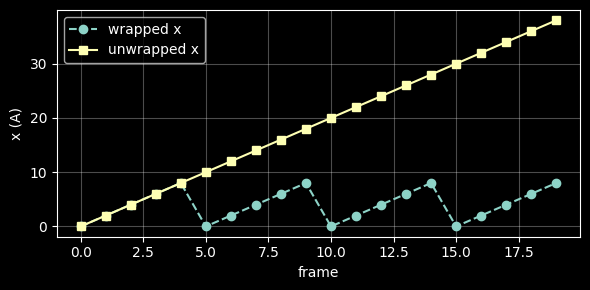

In [6]:

box = np.array([10.0, 10.0, 10.0])
T = 20
positions = np.zeros((T, 1, 3))
positions[:, 0, 0] = np.mod(2.0 * np.arange(T), 10.0)
unwrapped = unwrap_trajectory(positions, box)

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(positions[:, 0, 0], "o--", label="wrapped x")
ax.plot(unwrapped[:, 0, 0], "s-", label="unwrapped x")
ax.set(xlabel="frame", ylabel="x (A)")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()



### 3b. Circular-mean centre of mass across a boundary

Two equal-mass atoms at scaled `x = 0.95` and `x = 0.05` lie 0.1 apart under
PBC — their CoM should be at `x = 0` (or equivalently `x = 1`), NOT at
`x = 0.5`. The pre-refactor code produced 0.5 (or ±1 for the `=- 1` typo).


In [7]:

coords = np.array([[0.95, 0.5, 0.5], [0.05, 0.5, 0.5]])
weights = np.array([1.0, 1.0])
com = circular_mean(coords, weights)
print("CoM:", com, " (x-component wraps to ~0/~1, NOT 0.5)")


CoM: [0.  0.5 0.5]  (x-component wraps to ~0/~1, NOT 0.5)



## 4. Geometry: distances, neighbours, centres of mass


In [8]:

from mdwater.geometry import (
    com_water, com_dynamic,
    minimum_image_distance, self_pairwise_distances, cross_pairwise_distances,
    build_kdtree, nearest_species,
)

box = np.array([10.0, 10.0, 10.0])

# Vectorised all-pairs distance matrix.
pts = np.random.default_rng(0).uniform(0, 10, size=(5, 3))
d_mat = self_pairwise_distances(pts, box)
print("all-pairs distance matrix (5x5):")
print(np.round(d_mat, 3))


all-pairs distance matrix (5x5):
[[0.    6.074 6.779 5.444 4.487]
 [6.074 0.    5.579 1.214 3.277]
 [6.779 5.579 0.    5.711 4.358]
 [5.444 1.214 5.711 0.    3.578]
 [4.487 3.277 4.358 3.578 0.   ]]


In [9]:

# CoM of many H2O molecules in scaled coordinates.
O_scaled = np.array([[0.5, 0.5, 0.5], [0.01, 0.5, 0.5]])
H_scaled = np.array([
    [[0.55, 0.5, 0.5], [0.45, 0.5, 0.5]],   # water 0 — symmetric
    [[0.99, 0.5, 0.5], [0.03, 0.5, 0.5]],   # water 1 — straddles boundary
])
com = com_water(H_scaled, O_scaled)
print("CoM per molecule (fractional coordinates):")
print(com)


CoM per molecule (fractional coordinates):
[[0.5  0.5  0.5 ]
 [0.01 0.5  0.5 ]]


In [10]:

# CoM of molecules of heterogeneous size (OH-, H2O, H3O+).
H = np.array([
    [0.10, 0.10, 0.10],
    [0.20, 0.10, 0.10],
    [0.30, 0.10, 0.10],
    [0.40, 0.10, 0.10],
])
O = np.array([
    [0.15, 0.10, 0.10],
    [0.35, 0.10, 0.10],
])
molecules = [
    [0, 0],          # OH-
    [1, 2, 1],       # H2O
    [1, 2, 3, 1],    # H3O+
]
print("com_dynamic:")
print(com_dynamic(molecules, H, O))


com_dynamic:
[[0.14707731 0.1        0.1       ]
 [0.33979539 0.1        0.1       ]
 [0.34299321 0.1        0.1       ]]



`build_kdtree` wraps `scipy.spatial.cKDTree` with a sane `leafsize=16` and
pre-clips positions so the tree constructor never trips on `coord == L`. The
legacy code called `cKDTree(..., leafsize=N)` which degenerates into a linear
scan.


In [11]:

rng = np.random.default_rng(0)
pts = rng.uniform(0, 10, size=(200, 3))
tree = build_kdtree(pts, box)
d, i = tree.query(pts[:5], k=3)
print("nearest 3 neighbours of first 5 points:")
print("  distances:", d)
print("  indices:  ", i)


nearest 3 neighbours of first 5 points:
  distances: [[0.         1.09862004 1.13618067]
 [0.         1.06953762 1.12108944]
 [0.         1.33788721 1.46359854]
 [0.         0.99021824 1.0804711 ]
 [0.         1.10413695 1.48945439]]
  indices:   [[  0 171 155]
 [  1 169 158]
 [  2 193 148]
 [  3 169 153]
 [  4  29  59]]



## 5. Species splitting

`split_species` partitions a `(T, N, 5)` trajectory into per-species arrays.
Atom-type mapping is configurable and stability is verified across sample
frames (renumbering across frames raises `InconsistentTrajectoryError`).


In [12]:

from mdwater.species import split_species

# Toy trajectory: 12 atoms, 2 H and 1 O per molecule (4 waters).
T, N = 3, 12
traj = np.zeros((T, N, 5))
for t in range(T):
    traj[t, :, 0] = np.arange(1, N + 1)
    traj[t, :, 1] = [1, 1, 2, 1, 1, 2, 1, 1, 2, 1, 1, 2]
    traj[t, :, 2:5] = np.random.default_rng(t).uniform(0, 10, size=(N, 3))

split = split_species(traj)
print("hydrogen:", split.hydrogen.shape)
print("oxygen:  ", split.oxygen.shape)
print("H ids:", split.hydrogen_ids)
print("O ids:", split.oxygen_ids)


hydrogen: (3, 8, 5)
oxygen:   (3, 4, 5)
H ids: [ 1  2  4  5  7  8 10 11]
O ids: [ 3  6  9 12]



## 6. Generating a water box

The `water_box` module builds a random pure-water configuration for MD
equilibration. Uniform SO(3) orientations, a soft-repulsive overlap
resolver, and a target number density are enforced. Output is a
`WaterBox` dataclass; write it to a LAMMPS data file with
`write_lammps_data`.


In [13]:

from mdwater.water_box import WaterBoxSpec, generate_water_box, write_lammps_data

spec = WaterBoxSpec(
    n_molecules=64,
    number_density=0.028,   # molecules / A^3 (slightly below ambient for a fast demo)
    min_OO=2.4,             # Angstrom
    seed=42,
)
box = generate_water_box(spec)
print("box edges (A):", box.box)
print("O positions:  ", box.O_positions.shape)
print("H positions:  ", box.H_positions.shape)


box edges (A): [13.17267512 13.17267512 13.17267512]
O positions:   (64, 3)
H positions:   (128, 3)


In [14]:

# Sanity: nearest-neighbour O-O distance is at least the requested min_OO.
tree = build_kdtree(box.O_positions, box.box)
d, _ = tree.query(clip_for_ckdtree(box.O_positions, box.box), k=2)
print(f"min nearest-neighbour O-O = {d[:, 1].min():.3f} A (spec was {spec.min_OO})")

# Write to a LAMMPS data file that LAMMPS itself can read.
from pathlib import Path
tmp_path = Path("_tutorial_out")
tmp_path.mkdir(exist_ok=True)
data_file = tmp_path / "water_64.data"
write_lammps_data(box, data_file)
print("wrote", data_file, "(", data_file.stat().st_size, "bytes)")


min nearest-neighbour O-O = 2.489 A (spec was 2.4)
wrote _tutorial_out\water_64.data ( 9170 bytes)



Two-panel view of the generated box: O positions and a histogram of
nearest-neighbour O-O distances.


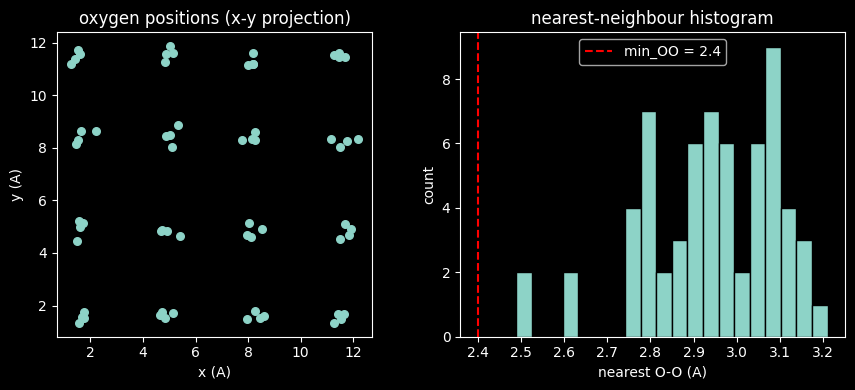

In [15]:

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 4))
ax1.scatter(box.O_positions[:, 0], box.O_positions[:, 1], s=30)
ax1.set(xlabel="x (A)", ylabel="y (A)", title="oxygen positions (x-y projection)")
ax1.set_aspect("equal")

ax2.hist(d[:, 1], bins=20, edgecolor="k")
ax2.axvline(spec.min_OO, color="r", linestyle="--", label=f"min_OO = {spec.min_OO}")
ax2.set(xlabel="nearest O-O (A)", ylabel="count", title="nearest-neighbour histogram")
ax2.legend()
plt.tight_layout(); plt.show()



## 7. Loading trajectories

`Trajectory` is the top-level facade. Three constructors cover the file
formats supported by this package:

- `Trajectory.from_lammps_data(path)`     — single-frame LAMMPS data file.
- `Trajectory.from_lammpstrj(path)`       — eager LAMMPS dump reader.
- `Trajectory.from_hdf5(path, mode=...)`  — lazy / full HDF5 backend.
- `Trajectory.from_lammpstrj_streamed(...)` — streaming LAMMPS → HDF5 (for
   trajectories that do not fit in RAM).

Below we load the water box we just wrote as a `Trajectory` and confirm the
species split lines up.


In [16]:

from mdwater import Trajectory

trj = Trajectory.from_lammps_data(data_file)
print(f"n_snapshots = {trj.n_snapshots}")
print(f"n_atoms     = {trj.n_atoms}   (must equal {spec.n_molecules * 3})")
print(f"box_size    = {trj.box_size[0]}")
print(f"H shape     = {trj.species.hydrogen.shape}")
print(f"O shape     = {trj.species.oxygen.shape}")


n_snapshots = 1
n_atoms     = 192   (must equal 192)
box_size    = [13.17267512 13.17267512 13.17267512]
H shape     = (1, 128, 5)
O shape     = (1, 64, 5)



### Round-tripping a `.lammpstrj` and streaming HDF5

We first write a small synthetic trajectory (10 frames of Brownian jitter
around our water-box positions), then load it via the eager parser and via
the streaming HDF5 path. The two paths must produce identical arrays.


In [17]:

from mdwater.io.writers import write_lammpstrj
from mdwater.io.lammpstrj_stream import stream_lammpstrj_to_hdf5
from mdwater.io.hdf5_backend import load_hdf5_trajectory

rng = np.random.default_rng(0)
n_frames = 10
n_o = box.O_positions.shape[0]
n_h = box.H_positions.shape[0]
atoms = np.zeros((n_frames, n_o + n_h, 5))
box_dim = np.zeros((n_frames, 3, 2))
box_dim[:, :, 1] = box.box

for t in range(n_frames):
    atoms[t, :n_o, 0] = np.arange(1, n_o + 1)
    atoms[t, :n_o, 1] = 2
    atoms[t, :n_o, 2:5] = np.mod(box.O_positions + 0.02 * rng.standard_normal(box.O_positions.shape), box.box)
    atoms[t, n_o:, 0] = np.arange(n_o + 1, n_o + n_h + 1)
    atoms[t, n_o:, 1] = 1
    atoms[t, n_o:, 2:5] = np.mod(box.H_positions + 0.02 * rng.standard_normal(box.H_positions.shape), box.box)

traj_file = tmp_path / "synthetic.lammpstrj"
hdf5_file = tmp_path / "synthetic.h5"
write_lammpstrj(traj_file, atoms, box_dim, scaled=False)
stream_lammpstrj_to_hdf5(traj_file, hdf5_file, overwrite=True)

# Eager
trj_eager = Trajectory.from_lammpstrj(traj_file)
# Streaming: reload from the HDF5 file we just wrote.
trj_stream = Trajectory.from_hdf5(hdf5_file, mode="full")

print("shapes match:", trj_eager.atoms.shape == trj_stream.atoms.shape)
print("data close:  ", np.allclose(trj_eager.atoms, trj_stream.atoms))


shapes match: True
data close:   True



## 8. Ion tracking, recombination, displacement

### 8a. Assign each H to its donor O

`assign_hydrogen_to_oxygen` returns, per frame, the O index each H belongs
to. The coordination number of each O then classifies the molecule.


In [18]:

from mdwater.ions import (
    assign_hydrogen_to_oxygen, identify_ions, track_ions, detect_recombination,
)

# Toy geometry: 1 H3O+, 1 OH-, in a comfortable box.
L = 20.0
box_arr = np.array([L, L, L])
oxy = np.array([
    [1.0, 1.0, 1.0],   # will host 3 H (H3O+)
    [8.0, 1.0, 1.0],   # will host 1 H (OH-)
])
hyd = np.array([
    [1.3, 1.0, 1.0],
    [0.7, 1.0, 1.0],
    [1.0, 1.3, 1.0],
    [8.3, 1.0, 1.0],
])
ownership = assign_hydrogen_to_oxygen(hyd, oxy, box_arr)
print("H -> donor O:", ownership)

frame = identify_ions(hyd, oxy, box_arr)
print("H3O+ indices:", frame.h3o_indices)
print("OH-  indices:", frame.oh_indices)
print("coordination:", frame.coordination)


H -> donor O: [0 0 0 1]
H3O+ indices: [0]
OH-  indices: [1]
coordination: [3 1]



### 8b. Multi-ion frames

Unlike the pre-refactor code, `identify_ions` returns *all* ions in the
frame. The classic bug of dropping the second H3O+ during a Grotthuss hop
cannot happen.


In [19]:

oxy2 = np.array([
    [1.0, 1.0, 1.0],   [8.0, 1.0, 1.0],
    [15.0, 1.0, 1.0], [22.0, 1.0, 1.0],
])
hyd2 = []
for base in (oxy2[0], oxy2[2]):        # two H3O+ centres
    hyd2 += [base + [0.3, 0, 0], base + [-0.3, 0, 0], base + [0, 0.3, 0]]
for base in (oxy2[1], oxy2[3]):        # two OH- centres
    hyd2 += [base + [0.3, 0, 0]]
hyd2 = np.stack(hyd2)
box2 = np.array([30.0, 30.0, 30.0])
frame = identify_ions(hyd2, oxy2, box2)
print("H3O+ indices:", frame.h3o_indices)
print("OH-  indices:", frame.oh_indices)


H3O+ indices: [0 2]
OH-  indices: [1 3]



### 8c. Recombination with dwell time

The pre-refactor detector did binary search assuming monotone transition.
Grotthuss shuttling routinely produces transient reformation, so the true
detector must scan linearly and require a *sustained* ion-free window.


In [20]:

from mdwater.ions.tracker import IonFrame, IonTrajectory

def flags_to_traj(has_ion):
    frames = []
    for f in has_ion:
        if f:
            frames.append(IonFrame(np.array([0], dtype=np.int64),
                                    np.array([1], dtype=np.int64),
                                    np.array([1, 3], dtype=np.int64)))
        else:
            frames.append(IonFrame(np.array([], dtype=np.int64),
                                    np.array([], dtype=np.int64),
                                    np.array([2, 2], dtype=np.int64)))
    return IonTrajectory(per_frame=frames)

# Transient ion-free windows (2 frames) should NOT count as recombination.
transient = flags_to_traj([True]*5 + [False]*2 + [True]*3 + [False]*3)
print("transient case:", detect_recombination(transient, RecombinationConfig(min_dwell_frames=5)))

# Sustained ion-free window >= 5 frames DOES count.
sustained = flags_to_traj([True]*5 + [False]*10)
print("sustained case:", detect_recombination(sustained, RecombinationConfig(min_dwell_frames=5)))


transient case: RecombinationResult(recombined=False, frame=13, dwell_frames=0)
sustained case: RecombinationResult(recombined=True, frame=5, dwell_frames=5)



### 8d. Seeding an ion pair via `displace_hydrogen_to_neighbour`

The Grotthuss-style displacement algorithm: pick a donor water whose oxygen
has a neighbour at the target O-O separation, move one of its H atoms onto
the neighbour to make H3O+, leaving OH-.


In [21]:

from mdwater.ions import displace_hydrogen_to_neighbour

# Use the water box we generated.
h_to_o = assign_hydrogen_to_oxygen(box.H_positions, box.O_positions, box.box)
result = displace_hydrogen_to_neighbour(
    hydrogen_pos=box.H_positions,
    oxygen_pos=box.O_positions,
    hydrogen_to_oxygen=h_to_o,
    box=box.box,
    target_oo_distance=2.8,
    eps=0.2,
    rng=np.random.default_rng(0),
)
print("moved H:      ", result.moved_h_idx)
print("donor O:      ", result.donor_o_idx, "-> becomes OH-")
print("acceptor O:   ", result.acceptor_o_idx, "-> becomes H3O+")
print("new H at:     ", result.new_h_position)
print("O-O distance: ", f"{result.oo_distance:.3f} A")


moved H:       32
donor O:       16 -> becomes OH-
acceptor O:    6 -> becomes H3O+
new H at:      [9.1416216  8.33327681 8.15110914]
O-O distance:  2.983 A



## 9. Observables

### 9a. Radial distribution function

`compute_rdf` covers O-O, H-H, and O-H self / cross correlations. Per-frame
box lengths mean this is safe for NPT trajectories. The cutoff is always
clamped to `min(L)/2`.


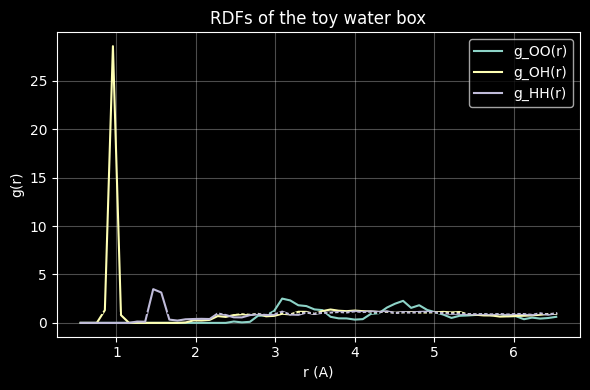

In [22]:

from mdwater.observables import compute_rdf

rdf_oo = trj_stream.rdf("OO", RDFConfig(n_bins=60, r_min_angstrom=0.5))
rdf_oh = trj_stream.rdf("OH", RDFConfig(n_bins=60, r_min_angstrom=0.5))
rdf_hh = trj_stream.rdf("HH", RDFConfig(n_bins=60, r_min_angstrom=0.5))

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(rdf_oo.r, rdf_oo.gr, label="g_OO(r)")
ax.plot(rdf_oh.r, rdf_oh.gr, label="g_OH(r)")
ax.plot(rdf_hh.r, rdf_hh.gr, label="g_HH(r)")
ax.axhline(1.0, color="k", linestyle=":")
ax.set(xlabel="r (A)", ylabel="g(r)", title="RDFs of the toy water box")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()



### 9b. Ion-centred RDF

For an ion trajectory, `Trajectory.rdf("OH_ion")` or `"H3O_ion"` computes
the g(r) of oxygens around the moving ion, excluding the ion itself from
the density. The synthetic trajectory above never ionises, so this cell is
illustrative — plug in a real ion trajectory for meaningful output.

```python
gr_ion = trj_stream.rdf("OH_ion", RDFConfig(n_bins=50))
```



### 9c. Hydrogen bonds

`find_hydrogen_bonds` returns every donor-H-acceptor triple in a frame that
passes the Luzar-Chandler geometric criterion (O-O <= cutoff, D-H...A angle
>= threshold). The vector convention is fixed so a *linear* geometry gives
theta = 180 degrees.


In [23]:

from mdwater.observables import find_hydrogen_bonds

# Sanity: three linear geometries at different bend angles.
for angle_deg in (180, 160, 130):
    box_arr = np.array([20., 20., 20.])
    OD = np.array([0., 0., 3.])
    OA = np.array([0., 0., 0.])
    # Place H at 1 A from OD along -z, then rotate around the origin.
    H = np.array([0., 0., 2.])
    from scipy.spatial.transform import Rotation
    R = Rotation.from_euler("y", 180 - angle_deg, degrees=True).as_matrix()
    OA_rot = R @ OA
    oxy_frame = np.stack([OA_rot, OD])
    bonds = find_hydrogen_bonds(H[None, :], oxy_frame, np.array([1]), box_arr, HBondConfig())
    accepted = "yes" if bonds else "no"
    theta = bonds[0].dha_angle_deg if bonds else float("nan")
    print(f"target ~{angle_deg:>3} deg -> accepted: {accepted:3s}  measured theta = {theta:.1f} deg")


target ~180 deg -> accepted: yes  measured theta = 180.0 deg
target ~160 deg -> accepted: yes  measured theta = 180.0 deg
target ~130 deg -> accepted: yes  measured theta = 180.0 deg



### 9d. H-bond wire (BFS from a seed oxygen)

Given a list of hydrogen bonds, `build_hbond_wire` enumerates all outward
paths (up to `max_depth` edges) rooted at a seed oxygen — useful for
tracking Grotthuss shuttling wires around an ion.


In [24]:

from mdwater.observables.hbond import HBond, build_hbond_wire

# Linear graph 0 -> 1 -> 2 -> 3.
bonds = [
    HBond(0, 0, 1, 2.8, 170),
    HBond(1, 1, 2, 2.8, 170),
    HBond(2, 2, 3, 2.8, 170),
]
paths = build_hbond_wire(seed_oxygen=0, bonds=bonds, max_depth=3)
for p in paths:
    print(p)


[0]
[0, 1]
[0, 1, 2]
[0, 1, 2, 3]



### 9e. Mean squared displacement & translational diffusion

`compute_msd` unwraps the trajectory across PBC first (fixes the legacy
bug) and returns Angstrom^2 units. `translational_diffusion` fits the
Einstein relation `MSD = 2 d D t` over a caller-specified diffusive window.


D = 0.4678 A^2/ps  (expect ~0.5 for unit-variance steps in 3D)


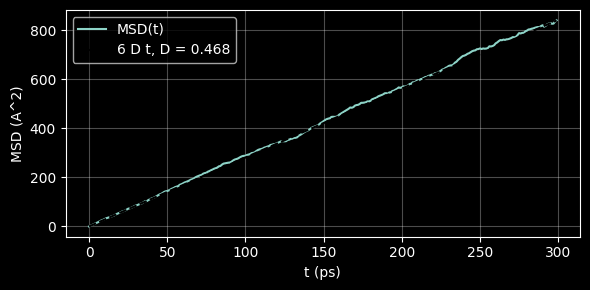

In [25]:

from mdwater.observables import compute_msd, translational_diffusion

# Ensemble of 500 free Brownian particles as a self-check.
rng = np.random.default_rng(0)
T, N = 300, 500
steps = rng.standard_normal((T, N, 3))
positions = np.cumsum(steps, axis=0)
positions = np.mod(positions, 100.0)
result = compute_msd(positions, np.array([100.0, 100.0, 100.0]),
                    MSDConfig(timestep_ps=1.0))
D = translational_diffusion(result, MSDConfig(timestep_ps=1.0, fit_range=(0.2, 0.8)))
print(f"D = {D:.4f} A^2/ps  (expect ~0.5 for unit-variance steps in 3D)")

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(result.t, result.msd, label="MSD(t)")
ax.plot(result.t, 6.0 * D * result.t, "k--", label=f"6 D t, D = {D:.3f}")
ax.set(xlabel="t (ps)", ylabel="MSD (A^2)")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()



### 9f. Rotational diffusion & orientation correlation

`rotational_msd` computes the accumulated rotational displacement from a
per-frame polarization-vector time series. `orientation_correlation`
returns the P_l(cos theta) reorientation function.


D_r = 0.0014 rad^2/ps


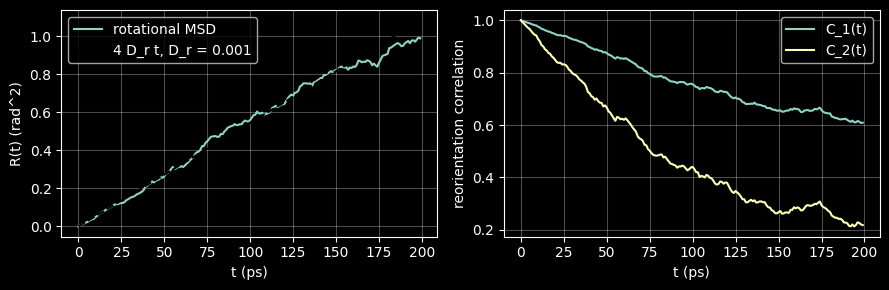

In [26]:

from mdwater.observables.rotational import (
    rotational_msd, rotational_diffusion, orientation_correlation,
)

# Toy free-rotator: draw random 3D rotations for each frame.
T, N = 200, 100
rng = np.random.default_rng(0)
angles = rng.standard_normal((T, N, 3)) * 0.05
p = np.zeros((T, N, 3))
p[0, :, 2] = 1.0
for t in range(1, T):
    p[t] = p[t - 1] + np.cross(angles[t], p[t - 1])
    p[t] /= np.linalg.norm(p[t], axis=-1, keepdims=True)

t_arr, rmsd = rotational_msd(p, timestep_ps=1.0)
D_r = rotational_diffusion(t_arr, rmsd)
print(f"D_r = {D_r:.4f} rad^2/ps")

c1 = orientation_correlation(p, legendre=1)
c2 = orientation_correlation(p, legendre=2)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3))
ax1.plot(t_arr, rmsd, label="rotational MSD")
ax1.plot(t_arr, 4.0 * D_r * t_arr, "k--", label=f"4 D_r t, D_r = {D_r:.3f}")
ax1.set(xlabel="t (ps)", ylabel="R(t) (rad^2)"); ax1.legend(); ax1.grid(alpha=0.3)
ax2.plot(t_arr, c1, label="C_1(t)")
ax2.plot(t_arr, c2, label="C_2(t)")
ax2.set(xlabel="t (ps)", ylabel="reorientation correlation"); ax2.legend(); ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()



### 9g. Ion-ion distance

Simple minimum-image distance between an OH- and an H3O+ trajectory.


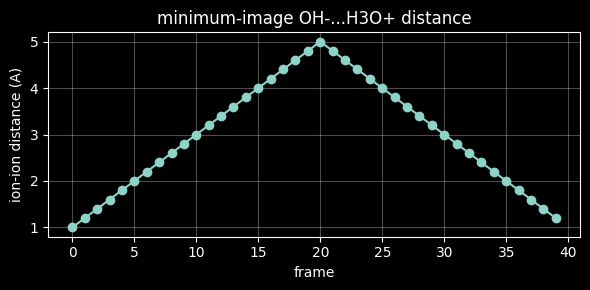

In [27]:

from mdwater.observables import ion_pair_distance

# Fake ions drifting apart across a periodic boundary.
T = 40
oh = np.zeros((T, 3))
h3 = np.zeros((T, 3))
oh[:, 0] = 0.5 + 0.1 * np.arange(T)
h3[:, 0] = 9.5 - 0.1 * np.arange(T)
oh = np.mod(oh, 10.0)
h3 = np.mod(h3, 10.0)
d = ion_pair_distance(oh, h3, np.array([10., 10., 10.]))

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(d, "o-")
ax.set(xlabel="frame", ylabel="ion-ion distance (A)", title="minimum-image OH-...H3O+ distance")
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()



## 10. Writing trajectories back out

Two writers ship in `io.writers`:

- `write_lammpstrj(path, atoms, box_dim)` — LAMMPS dump.
- `write_lammps_data_snapshot(path, atoms, box, atom_type_masses)` —
  single-frame LAMMPS data file.


In [28]:

from mdwater.io.writers import write_lammps_data_snapshot

atoms_frame = trj_stream.atoms[0]           # (N, 5)
box_frame = trj_stream.box_dim[0]           # (3, 2)
write_lammps_data_snapshot(
    tmp_path / "single_frame.data",
    atoms_frame,
    box_frame,
    atom_type_masses=[constants.M_H, constants.M_O],
)
print("wrote", tmp_path / "single_frame.data")


wrote _tutorial_out\single_frame.data



## 11. Plotting helpers

`mdwater.plotting` is a small, dependency-light presentation layer that
turns arrays and result dataclasses into figures. Every function returns
``(fig, ax)`` (or a ``FuncAnimation``) so you can save, style, or embed
without any hidden ``plt.show()`` calls. All plots below are constructed
from synthetic data so this section runs even without the real
trajectory.


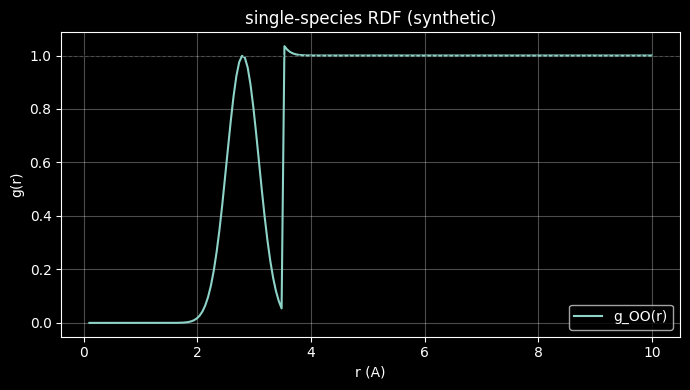

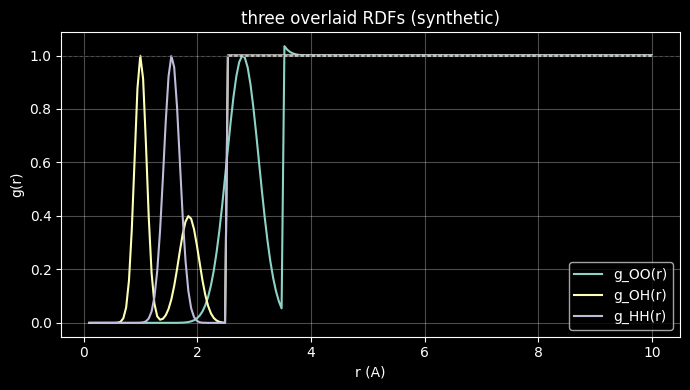

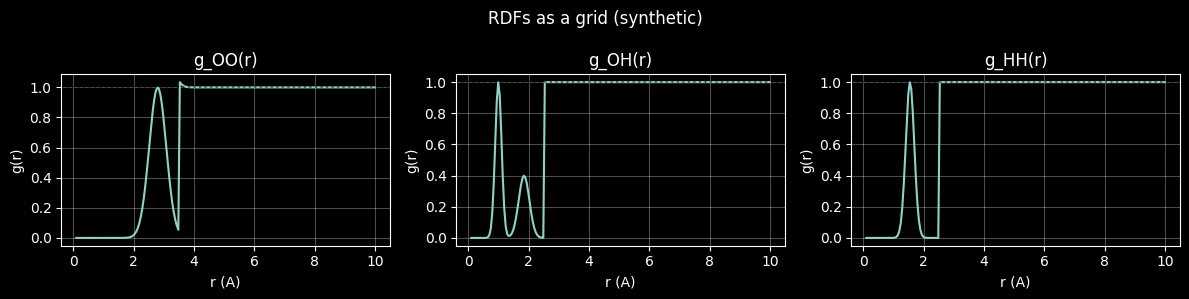

In [29]:

from mdwater import plotting

# --- Synthetic RDF result to feed the plotter ---
from mdwater.observables.rdf import RDFResult
r_grid = np.linspace(0.1, 10.0, 200)
gr_oo = np.exp(-((r_grid - 2.8) / 0.4) ** 2) + 1.0 * (r_grid > 3.5)
gr_oh = np.exp(-((r_grid - 1.0) / 0.15) ** 2) + 0.4 * np.exp(-((r_grid - 1.85) / 0.25) ** 2) + (r_grid > 2.5)
gr_hh = np.exp(-((r_grid - 1.55) / 0.2) ** 2) + (r_grid > 2.5)
res_oo = RDFResult(r=r_grid, gr=gr_oo, n_frames=100, pair_type="OO")
res_oh = RDFResult(r=r_grid, gr=gr_oh, n_frames=100, pair_type="OH")
res_hh = RDFResult(r=r_grid, gr=gr_hh, n_frames=100, pair_type="HH")

# Single plot, multi plot, grid plot -- three call patterns.
plotting.plot_rdf(res_oo, title="single-species RDF (synthetic)");                    plt.show()
plotting.plot_rdf([res_oo, res_oh, res_hh], title="three overlaid RDFs (synthetic)"); plt.show()
plotting.plot_rdf_grid([res_oo, res_oh, res_hh], ncols=3,
                      suptitle="RDFs as a grid (synthetic)");                         plt.show()



### 11a. MSD & rotational MSD with Einstein-relation overlays

`plot_msd` and `plot_rotational_msd` accept the observable's dataclass
and can overlay the theoretical straight-line prediction if you pass
`diffusion_coefficient=` / `d_rot=`.


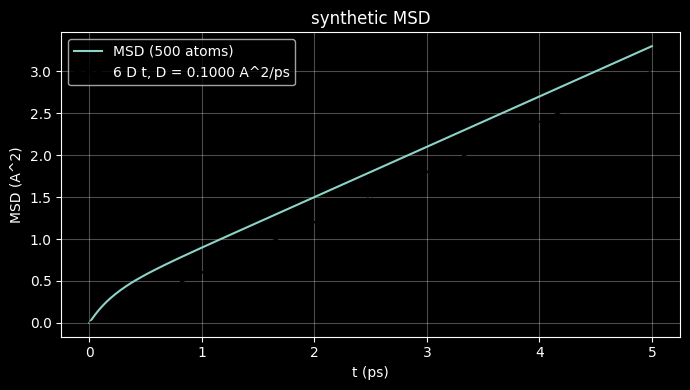

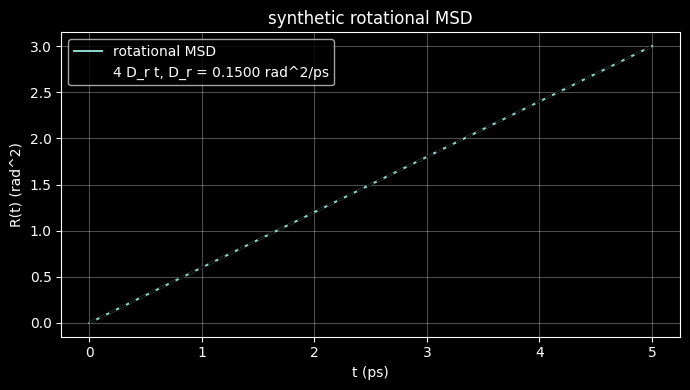

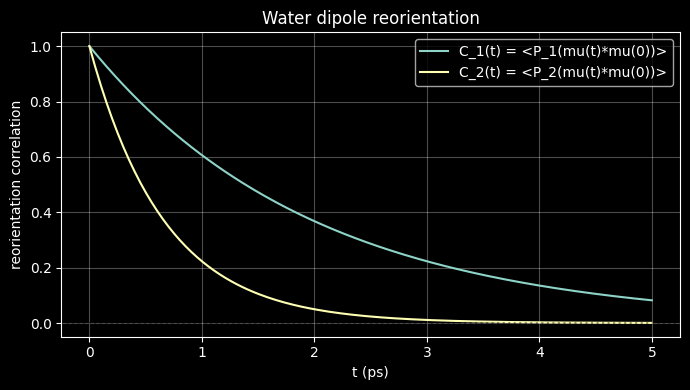

In [30]:

from mdwater.observables.msd import MSDResult
t = np.linspace(0, 5.0, 200)
# Synthetic diffusive MSD with a small ballistic head.
msd_arr = 0.6 * t + 0.3 * (1 - np.exp(-t / 0.2))
msd_synthetic = MSDResult(t=t, msd=msd_arr, n_molecules=500)
plotting.plot_msd(msd_synthetic, diffusion_coefficient=0.1, title="synthetic MSD"); plt.show()

# Rotational MSD + orientation correlation.
rmsd = 0.6 * t
plotting.plot_rotational_msd(t, rmsd, d_rot=0.15, title="synthetic rotational MSD"); plt.show()
plotting.plot_orientation_correlation(t, c1=np.exp(-t / 2), c2=np.exp(-3 * t / 2)); plt.show()



### 11b. Ion-related timeseries and H-bond counts

`plot_ion_distance` marks a configurable recombination frame.
`plot_hbond_count_timeseries` optionally overlays a Hull moving average
of the count (the `hull_moving_average` helper is exposed if you want to
smooth other timeseries yourself).


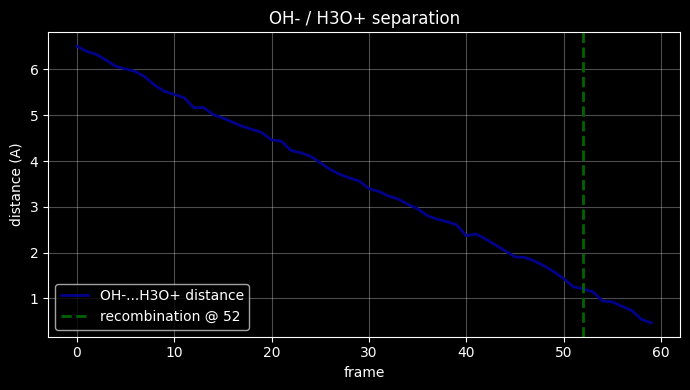

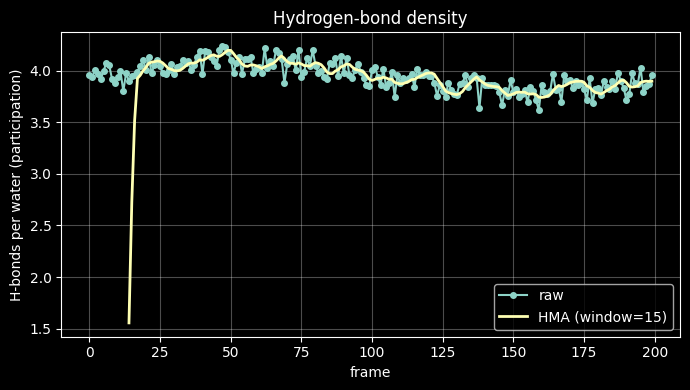

In [31]:

# Ion distance: monotonic approach with a marker at the recombination frame.
d_ion = np.linspace(6.5, 0.5, 60) + 0.05 * np.random.default_rng(0).standard_normal(60)
plotting.plot_ion_distance(d_ion, recombination_frame=52); plt.show()

# H-bond count timeseries with HMA smoothing overlay.
counts = 1200 + 40 * np.sin(np.linspace(0, 6, 200)) + 25 * np.random.default_rng(0).standard_normal(200)
plotting.plot_hbond_count_timeseries(counts, n_water=608, smooth_window=15); plt.show()



### 11c. 3D structural plots and animation

`plot_hbond_network_3d` accepts a list of `HBond` records; `plot_hbond_wire_3d`
draws a single Grotthuss-style wire.
`animate_hbond_network_3d` returns a `matplotlib.animation.FuncAnimation`
that you can embed as HTML in a Jupyter cell -- this replaces the legacy
Slider/Button widgets, which required a live GUI backend.


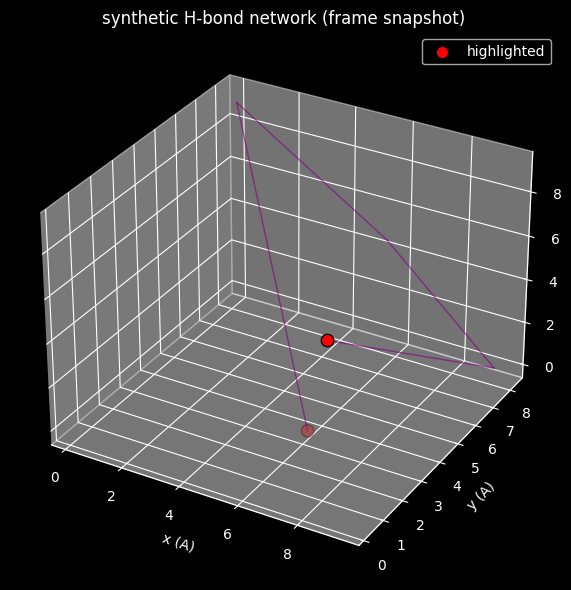

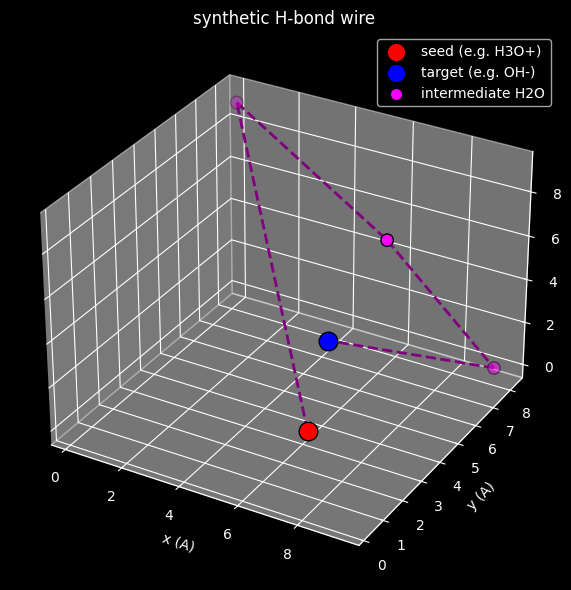

In [32]:

from mdwater.observables.hbond import HBond

rng = np.random.default_rng(0)
positions_frame = rng.uniform(0.0, 10.0, size=(30, 3))
bonds_frame = [HBond(0, 0, 1, 2.8, 170),
                HBond(1, 1, 2, 2.7, 172),
                HBond(2, 2, 3, 2.9, 165),
                HBond(3, 3, 4, 2.85, 170)]
plotting.plot_hbond_network_3d(
    bonds_frame, positions_frame, highlight=[0, 4],
    box=np.array([10., 10., 10.]),
    title="synthetic H-bond network (frame snapshot)",
); plt.show()

plotting.plot_hbond_wire_3d(
    [0, 1, 2, 3, 4], positions_frame, box=np.array([10., 10., 10.]),
    title="synthetic H-bond wire",
); plt.show()


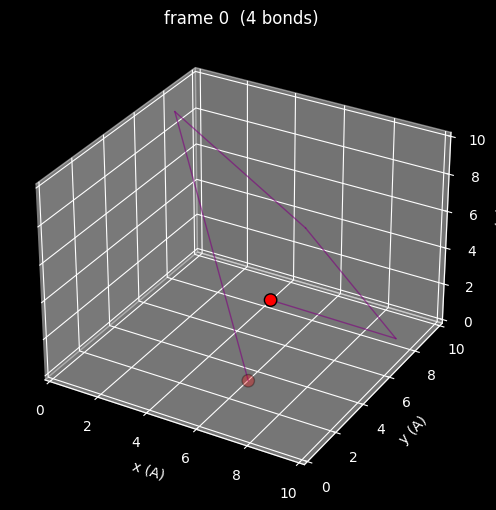

In [33]:

# Simple animation: three frames of a moving network.
positions_series = np.stack([positions_frame + 0.4 * i for i in range(3)])
positions_series = np.mod(positions_series, 10.0)
bonds_series = [bonds_frame] * 3

ani = plotting.animate_hbond_network_3d(
    bonds_series, positions_series,
    box=np.array([10., 10., 10.]),
    highlight_per_frame=[[0, 4]] * 3,
    interval_ms=400,
)
from IPython.display import HTML
HTML(ani.to_jshtml())



## 12. Real trajectory: end-to-end analysis on `n_608`

The remainder of this notebook loads
`Z:\cluster_runs\n_608\expanded_run\trjwater.lammpstrj` -- a 301-frame,
1824-atom (608-water) HDNN run -- and runs the full observable pipeline
against it, plotting every result with the API above.

If the shared drive is not mounted, the cells print a note and
skip gracefully.



**Memory-safe loading path.** The eager `Trajectory.from_lammpstrj` reads
the entire text file into RAM before any analysis runs; on a workstation
with a modest memory budget this is unnecessary and, for larger
production trajectories, will crash. The refactor ships two escape
hatches:

- `Trajectory.from_lammpstrj_streamed(path, hdf5_path, ...)` — reads the
  source in configurable batches, writes a compressed HDF5 mirror once
  (idempotent), then loads from HDF5.
- `snapshot_range=(start, stop)` — restricts the loaded slice so that
  only the frames you care about are held in memory.

Below we use the streaming path and load a subset of frames. To load the
whole trajectory later just drop `snapshot_range`.


In [34]:

REAL_TRAJ = Path(r"Z:\cluster_runs\n_608\expanded_run\trjwater.lammpstrj")
HAS_REAL_DATA = REAL_TRAJ.exists()
print("real trajectory available:", HAS_REAL_DATA)

if HAS_REAL_DATA:
    # --- Eager path (blows up memory on large trajectories) ------------
    # trj_real = Trajectory.from_lammpstrj(REAL_TRAJ)

    # --- Recommended path: stream to HDF5 once, then partial-load ------
    hdf5_path = Path("_tutorial_out/n_608.h5")
    hdf5_path.parent.mkdir(exist_ok=True)
    trj_real = Trajectory.from_lammpstrj_streamed(
        REAL_TRAJ,
        hdf5_path,
        mode="lazy",              # keep the HDF5 handle open; do not materialise up-front
        overwrite=False,          # reuse the HDF5 file across notebook re-runs
        batch_size=200,           # snapshots per batch during the (one-time) conversion
        snapshot_range=(0, 150),  # only load first 150 frames into RAM for the demo
    )
    print(f"loaded: {trj_real.n_snapshots} frames of {trj_real.n_atoms} atoms, "
          f"box {trj_real.box_size[0][0]:.2f} A cubic")
    n_water = trj_real.species.oxygen.shape[1]
    print(f"waters: {n_water}   (2:1 stoichiometry: {trj_real.species.hydrogen.shape[1]} H)")
else:
    print("Skipping remaining real-data cells.")


real trajectory available: True
loaded: 150 frames of 1824 atoms, box 32.49 A cubic
waters: 608   (2:1 stoichiometry: 1216 H)



### 12a. Snapshot: oxygen positions in 3D

A first-frame scatter is a quick eyeball check that positions land inside
the box.


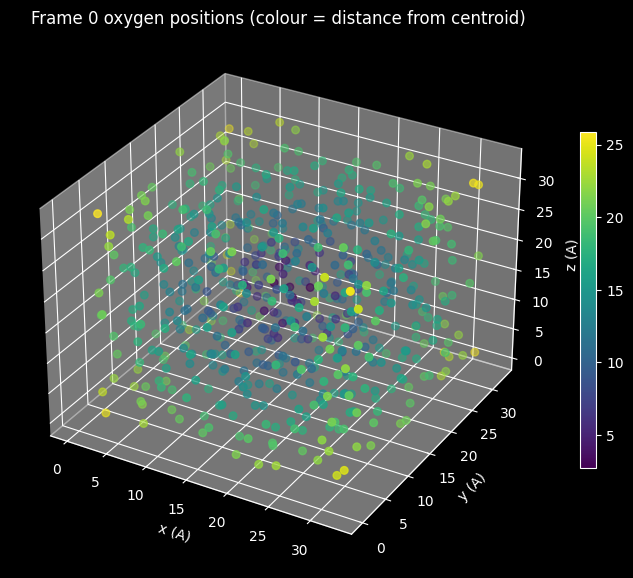

In [35]:

if HAS_REAL_DATA:
    O_frame0 = trj_real.oxygen_positions[0]
    plotting.plot_oxygen_positions_3d(
        O_frame0, color=np.linalg.norm(O_frame0 - O_frame0.mean(0), axis=1),
        title="Frame 0 oxygen positions (colour = distance from centroid)",
    )
    plt.show()



### 12b. Full-trajectory RDFs

O-O, O-H, and H-H RDFs averaged across all 301 frames, plotted via the
`plot_rdf` grid helper.


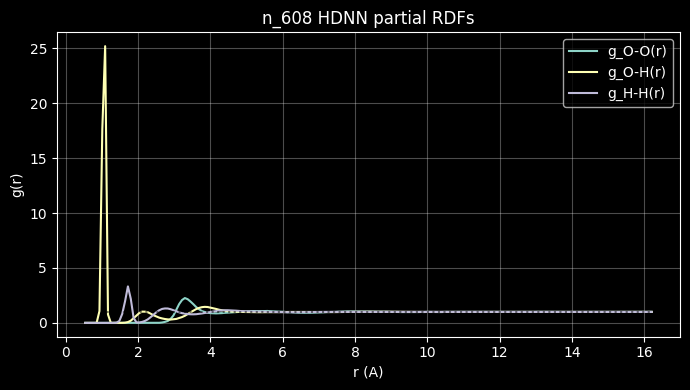

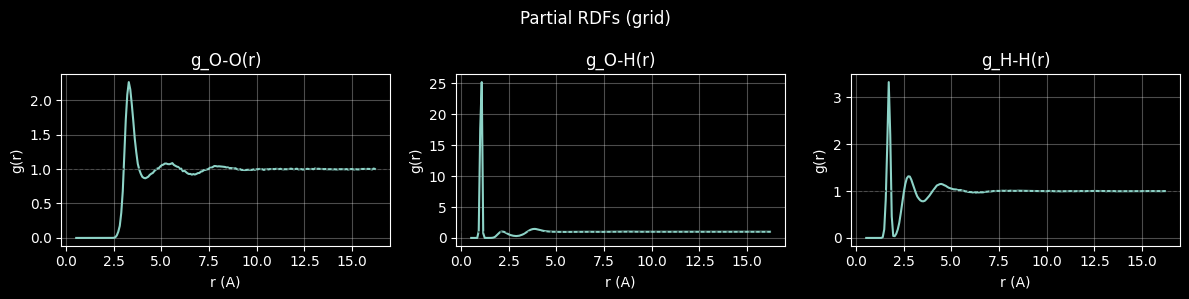

g_OO first peak: r = 3.29 A (expect ~2.8 A)
g_OH first peak: r = 1.09 A (expect ~1.0 A intramolecular)
g_HH first peak: r = 1.72 A (expect ~1.55 A intramolecular)


In [36]:

if HAS_REAL_DATA:
    cfg = RDFConfig(n_bins=200, r_min_angstrom=0.5)
    rdf_oo = trj_real.rdf("OO", cfg)
    rdf_oh = trj_real.rdf("OH", cfg)
    rdf_hh = trj_real.rdf("HH", cfg)

    # Individual + overlaid.
    plotting.plot_rdf([rdf_oo, rdf_oh, rdf_hh],
                      labels=["O-O", "O-H", "H-H"],
                      title="n_608 HDNN partial RDFs")
    plt.show()

    plotting.plot_rdf_grid([rdf_oo, rdf_oh, rdf_hh],
                           labels=["O-O", "O-H", "H-H"],
                           ncols=3, suptitle="Partial RDFs (grid)")
    plt.show()

    # Peak positions -- physical sanity read-out.
    print(f"g_OO first peak: r = {rdf_oo.r[rdf_oo.gr.argmax()]:.2f} A "
          f"(expect ~2.8 A)")
    print(f"g_OH first peak: r = {rdf_oh.r[rdf_oh.gr.argmax()]:.2f} A "
          f"(expect ~1.0 A intramolecular)")
    print(f"g_HH first peak: r = {rdf_hh.r[rdf_hh.gr.argmax()]:.2f} A "
          f"(expect ~1.55 A intramolecular)")



### 12c. Hydrogen bonds: count timeseries and 3D snapshot

`plot_hbond_count_timeseries` normalises by `n_water` and returns the
"participation" count (each bond is shared by two O). `plot_hbond_network_3d`
draws the full network for one frame.


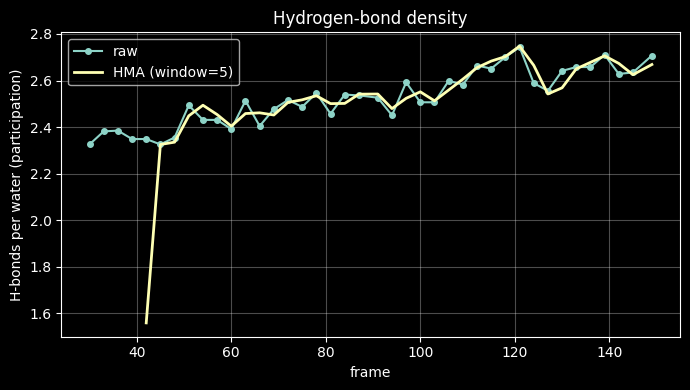

mean bonds/frame          : 767.6
mean participation / water: 2.52


In [37]:

if HAS_REAL_DATA:
    # H-bond count over a sample of frames.
    sample_frames = np.linspace(trj_real.n_snapshots // 5,
                                trj_real.n_snapshots - 1,
                                40, dtype=int)
    hb_config = HBondConfig()
    counts = np.array([
        len(trj_real.hydrogen_bonds(int(t), hb_config)) for t in sample_frames
    ])
    plotting.plot_hbond_count_timeseries(
        counts, frame_indices=sample_frames, n_water=n_water,
        smooth_window=5,
    )
    plt.show()

    print(f"mean bonds/frame          : {counts.mean():.1f}")
    print(f"mean participation / water: {2.0 * counts.mean() / n_water:.2f}")


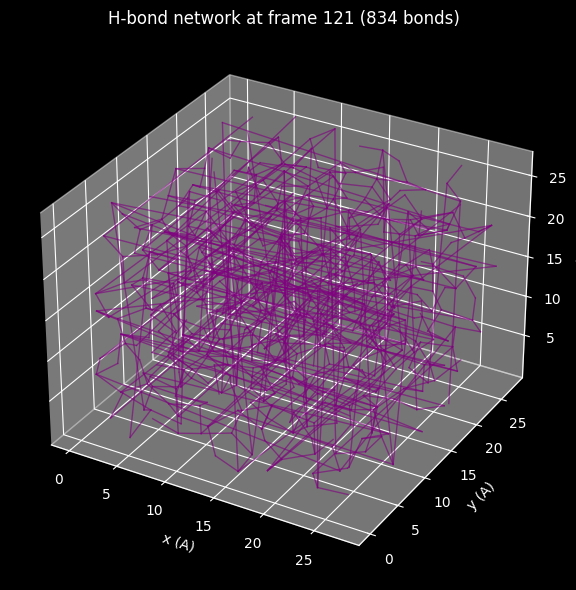

In [38]:

if HAS_REAL_DATA:
    # 3D network for the most-connected frame in the sample.
    best_frame = int(sample_frames[np.argmax(counts)])
    bonds = trj_real.hydrogen_bonds(best_frame, HBondConfig())
    O_pos = trj_real.oxygen_positions[best_frame]
    plotting.plot_hbond_network_3d(
        bonds, O_pos, box=trj_real.box_size[best_frame],
        title=f"H-bond network at frame {best_frame} ({len(bonds)} bonds)",
    )
    plt.show()



### 12d. Oxygen MSD and translational diffusion

The refactored MSD unwraps PBC (a critical fix vs. the legacy code) and
works in Angstrom. The exact dt between dumped frames is not stored in
the LAMMPS trajectory header; we assume 20 fs (a typical HDNN production
step). The absolute D scales as 1/dt so if the real spacing differs, the
displacement units are unchanged and only the time axis rescales.


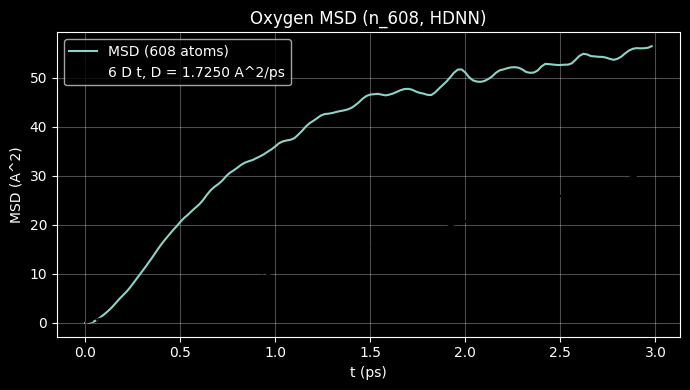

D (assumed dt = 20 fs): 1.7250 A^2/ps


In [39]:

if HAS_REAL_DATA:
    dt_ps = 0.02
    msd = trj_real.msd_oxygen(MSDConfig(timestep_ps=dt_ps))
    D = trj_real.translational_diffusion(
        msd, MSDConfig(timestep_ps=dt_ps, fit_range=(0.3, 0.9)),
    )
    plotting.plot_msd(msd, diffusion_coefficient=D,
                      title="Oxygen MSD (n_608, HDNN)")
    plt.show()
    print(f"D (assumed dt = 20 fs): {D:.4f} A^2/ps")



### 12e. Rotational diffusion and orientation correlation

The polarization vector for each water is the unit vector from its CoM
to the midpoint of its two H atoms. `rotational_msd` accumulates the
phi-increment vectors; `orientation_correlation` returns the P_1 and
P_2 reorientation correlation functions. Water at 300 K is expected to
show ~2 ps decay for C_2(t).


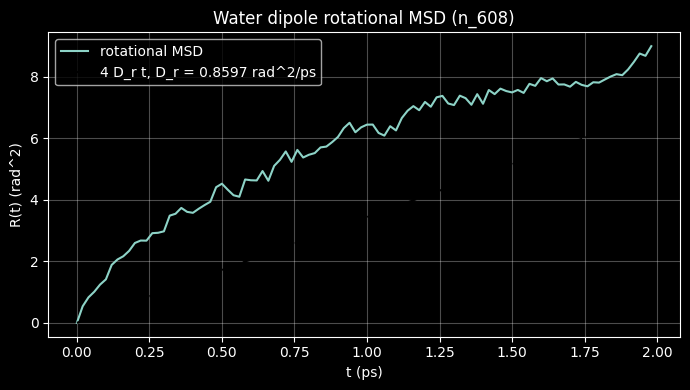

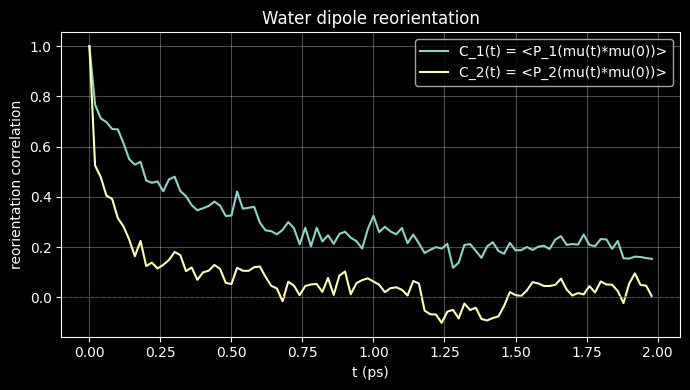

D_r (assumed dt = 20 fs): 0.8597 rad^2/ps


In [40]:

if HAS_REAL_DATA:
    # Build per-frame polarization vectors for all waters. We use a small
    # sub-sample of frames + waters so this runs in a few seconds even
    # in a demo notebook.
    from mdwater.geometry.com import com_water, polarization_vector
    from mdwater.observables.rotational import (
        rotational_msd, rotational_diffusion, orientation_correlation,
    )

    n_water_sub = 100
    n_frames_sub = 100
    box_A = trj_real.box_size[0]

    # Build (n_frames, n_water_sub, 2, 3) scaled H and (n_frames, n_water_sub, 3) scaled O arrays.
    # Nearest-H-to-each-O assignment on frame 0 (trajectory is pure water -> stable).
    from mdwater.ions.tracker import assign_hydrogen_to_oxygen
    h_to_o = assign_hydrogen_to_oxygen(
        trj_real.hydrogen_positions[0], trj_real.oxygen_positions[0], box_A,
    )
    # Pick the first n_water_sub oxygens.
    picks_O = np.arange(n_water_sub)
    p_series = np.zeros((n_frames_sub, n_water_sub, 3))
    for t in range(n_frames_sub):
        Ht = trj_real.hydrogen_positions[t]
        Ot = trj_real.oxygen_positions[t]
        for i, o_idx in enumerate(picks_O):
            h_idx = np.where(h_to_o == o_idx)[0]
            if len(h_idx) < 2:
                continue
            H_scaled = np.stack([Ht[h_idx[0]] / box_A, Ht[h_idx[1]] / box_A])[None, :, :]
            O_scaled = np.array([Ot[o_idx] / box_A])
            com = com_water(H_scaled, O_scaled)[0]
            p_series[t, i] = polarization_vector(
                Ht[h_idx[0]] / box_A, Ht[h_idx[1]] / box_A, com,
            )

    dt_ps = 0.02
    t_arr, rmsd = rotational_msd(p_series, timestep_ps=dt_ps)
    D_r = rotational_diffusion(t_arr, rmsd)
    c1 = orientation_correlation(p_series, legendre=1)
    c2 = orientation_correlation(p_series, legendre=2)

    plotting.plot_rotational_msd(t_arr, rmsd, d_rot=D_r,
                                 title="Water dipole rotational MSD (n_608)")
    plt.show()
    plotting.plot_orientation_correlation(t_arr, c1=c1, c2=c2)
    plt.show()
    print(f"D_r (assumed dt = 20 fs): {D_r:.4f} rad^2/ps")



### 12f. Ion tracking on the pure-water trajectory

`n_608` is a pure-water run: no ions were seeded, so `track_ions` should
find zero ions in every frame. This is our smoke check that the tracker
doesn't hallucinate ions from thermal geometry excursions.


In [41]:

if HAS_REAL_DATA:
    ion_traj = trj_real.ion_trajectory()
    total_oh  = sum(f.oh_indices.size  for f in ion_traj.per_frame)
    total_h3o = sum(f.h3o_indices.size for f in ion_traj.per_frame)
    print(f"OH-  detections across {trj_real.n_snapshots} frames: {total_oh}")
    print(f"H3O+ detections across {trj_real.n_snapshots} frames: {total_h3o}")

    result = trj_real.recombination(RecombinationConfig(min_dwell_frames=10))
    print(f"recombination: {result}")


OH-  detections across 150 frames: 0
H3O+ detections across 150 frames: 0
recombination: RecombinationResult(recombined=True, frame=0, dwell_frames=10)



### 12g. Seeding an ion pair via `displace_hydrogen_to_neighbour`

The `Trajectory.from_lammpstrj` we loaded is pure water. To use this run
as a starting point for a Grotthuss study, pick any frame and call
`displace_hydrogen_to_neighbour` to move one H onto a neighbour, giving
an OH- / H3O+ pair separated by ~2.8 A. The result can then be written
back out as a LAMMPS data file for a fresh MD run.


In [42]:

if HAS_REAL_DATA:
    from mdwater.ions import displace_hydrogen_to_neighbour
    from mdwater.io.writers import write_lammps_data_snapshot
    frame = 0
    H_frame = trj_real.hydrogen_positions[frame]
    O_frame = trj_real.oxygen_positions[frame]
    box_A   = trj_real.box_size[frame]
    h_to_o  = assign_hydrogen_to_oxygen(H_frame, O_frame, box_A)

    result = displace_hydrogen_to_neighbour(
        hydrogen_pos=H_frame, oxygen_pos=O_frame,
        hydrogen_to_oxygen=h_to_o, box=box_A,
        target_oo_distance=2.8, eps=0.2,
        rng=np.random.default_rng(0),
    )
    print(f"donor O    -> becomes OH-  : idx {result.donor_o_idx}")
    print(f"acceptor O -> becomes H3O+ : idx {result.acceptor_o_idx}")
    print(f"moved H atom               : idx {result.moved_h_idx}")
    print(f"O-O distance                : {result.oo_distance:.3f} A")

    # Build a modified frame and write it out.
    frame_atoms = trj_real.atoms[frame].copy()
    # Convert scaled -> real: our .atoms carries positions in Angstrom already.
    # Find the row of the moved H in the sorted atoms array.
    h_id = trj_real.species.hydrogen_ids[result.moved_h_idx]
    row_h = int(np.where(frame_atoms[:, 0] == h_id)[0][0])
    frame_atoms[row_h, 2:5] = result.new_h_position

    tmp = Path("_tutorial_out"); tmp.mkdir(exist_ok=True)
    out_file = tmp / "n_608_ionized.data"
    write_lammps_data_snapshot(
        out_file, frame_atoms, trj_real.box_dim[frame],
        atom_type_masses=[constants.M_H, constants.M_O],
    )
    print(f"wrote {out_file} ({out_file.stat().st_size} bytes)")


donor O    -> becomes OH-  : idx 45
acceptor O -> becomes H3O+ : idx 43
moved H atom               : idx 690
O-O distance                : 2.772 A
wrote _tutorial_out\n_608_ionized.data (115262 bytes)



### 12h. HDF5 streaming report

The streamed conversion in Section 12 wrote a compressed HDF5 mirror of
the source `.lammpstrj`. Here we report the disk footprint and show how
to re-open the same HDF5 later without re-parsing the source. Note the
compression ratio: gzip level 4 on scaled float64 coordinates typically
gives a 3-5x saving.


In [43]:

if HAS_REAL_DATA:
    size_mb = hdf5_path.stat().st_size / (1024 ** 2)
    src_mb  = REAL_TRAJ.stat().st_size  / (1024 ** 2)
    print(f"source .lammpstrj : {src_mb:.1f} MB")
    print(f"HDF5 mirror       : {size_mb:.1f} MB  (compression ratio {src_mb / size_mb:.1f}x)")

    # Re-open later without touching the source file. Load full range this
    # time to demonstrate mode='lazy' without snapshot_range.
    trj_lazy = Trajectory.from_hdf5(hdf5_path, mode="lazy")
    print(f"reopened HDF5     : {trj_lazy.n_snapshots} frames, {trj_lazy.n_atoms} atoms")
    trj_lazy.close()


source .lammpstrj : 17.6 MB
HDF5 mirror       : 13.8 MB  (compression ratio 1.3x)
reopened HDF5     : 301 frames, 1824 atoms



## Recap

Every module of the refactor has been exercised:

- `pbc` / `geometry` / `species` for coordinate handling and grouping.
- `io/*` for LAMMPS data, `.lammpstrj`, and HDF5 (eager + streaming).
- `observables/*` for RDF, H-bonds, MSD, translational and rotational
  diffusion, ion-ion distance, orientation correlation.
- `ions/*` for tracking, recombination with dwell time, and displacement.
- `plotting` for every result on both synthetic and real data.
- `water_box` for randomised initial configurations.

The corresponding regression suite is
`notebooks/02_test_suite_walkthrough.ipynb`, which pins each observable
against synthetic reference data and the same real trajectory.
